In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')

In [4]:
deliveries = pd.read_csv('deliveries.csv')
matches = pd.read_csv('matches.csv')

In [6]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [7]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [8]:
matches.shape

(1095, 20)

In [9]:
deliveries.shape


(260920, 17)

In [10]:
matches['team1'].value_counts()

,count
team1,
Royal Challengers Bangalore,135
Chennai Super Kings,128
Mumbai Indians,123
Kolkata Knight Riders,121
Rajasthan Royals,101
Kings XI Punjab,92
Sunrisers Hyderabad,86
Delhi Daredevils,85
Delhi Capitals,41


In [11]:
matches['team2'].value_counts()

,count
team2,
Mumbai Indians,138
Kolkata Knight Riders,130
Rajasthan Royals,120
Chennai Super Kings,110
Royal Challengers Bangalore,105
Kings XI Punjab,98
Sunrisers Hyderabad,96
Delhi Daredevils,76
Delhi Capitals,50


In [12]:
deliveries['batting_team'].value_counts()

,count
batting_team,
Mumbai Indians,31437
Kolkata Knight Riders,29514
Chennai Super Kings,28651
Royal Challengers Bangalore,28205
Rajasthan Royals,26242
Kings XI Punjab,22646
Sunrisers Hyderabad,21843
Delhi Daredevils,18786
Delhi Capitals,10946


In [15]:
matches['team1'] = matches['team1'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'})
matches['team2'] = matches['team2'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'})
matches['toss_winner'] = matches['toss_winner'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'})
matches['winner'] = matches['winner'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'})

In [17]:
matches['team1'] = matches['team1'].replace({'Royal Challengers Bengaluru':'Royal Challengers Bengaluru'})
matches['team2'] = matches['team2'].replace({'Royal Challengers Bengalurus':'Royal Challengers Bengaluru'})
matches['toss_winner'] = matches['toss_winner'].replace({'Royal Challengers Bengalurus':'Royal Challengers Bengaluru'})
matches['winner'] = matches['winner'].replace({'Royal Challengers Bengalurus':'Royal Challengers Bengaluru'})

In [18]:

matches['team2'].value_counts()

,count
team2,
Mumbai Indians,138
Kolkata Knight Riders,130
Rajasthan Royals,120
Royal Challengers Bangalore,111
Chennai Super Kings,110
Kings XI Punjab,98
Sunrisers Hyderabad,96
Delhi Daredevils,76
Delhi Capitals,50


In [19]:

deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [23]:
deliveries['batting_team'] = deliveries['batting_team'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'})
deliveries['bowling_team'] = deliveries['bowling_team'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'})

deliveries['batting_team'] = deliveries['batting_team'].replace({'Royal Challengers Bengaluru':'Royal Challengers Bangalore'})
deliveries['bowling_team'] = deliveries['bowling_team'].replace({'Royal Challengers Bengaluru':'Royal Challengers Bangalore'})


In [24]:
deliveries['batting_team'].value_counts()

,count
batting_team,
Mumbai Indians,31437
Royal Challengers Bangalore,30023
Kolkata Knight Riders,29514
Chennai Super Kings,28651
Rajasthan Royals,26242
Kings XI Punjab,22646
Sunrisers Hyderabad,21843
Delhi Daredevils,18786
Delhi Capitals,10946


In [25]:

matches['city'].isna().sum()

np.int64(51)

In [26]:
matches['method'].value_counts()

,count
method,
D/L,21


In [29]:
matches['city'] = matches['city'].fillna('Unknown')
matches['method'] = matches['method'].fillna('Non D/L')

In [30]:
def random_colors(no_of_colors):
    return ['#'+''.join([np.random.choice(list('0123456789ABCDEF')) for _ in range(6)]) for _ in range(no_of_colors)]


In [31]:
random_colors(6)



['#4B48C2', '#EC7A60', '#C20314', '#6DEE07', '#128973', '#8EB641']

/tmp/ipykernel_1341/1010771273.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=success_ratio_desc.index,y=success_ratio_desc.values, palette=random_colors(len(success_ratio_desc)))


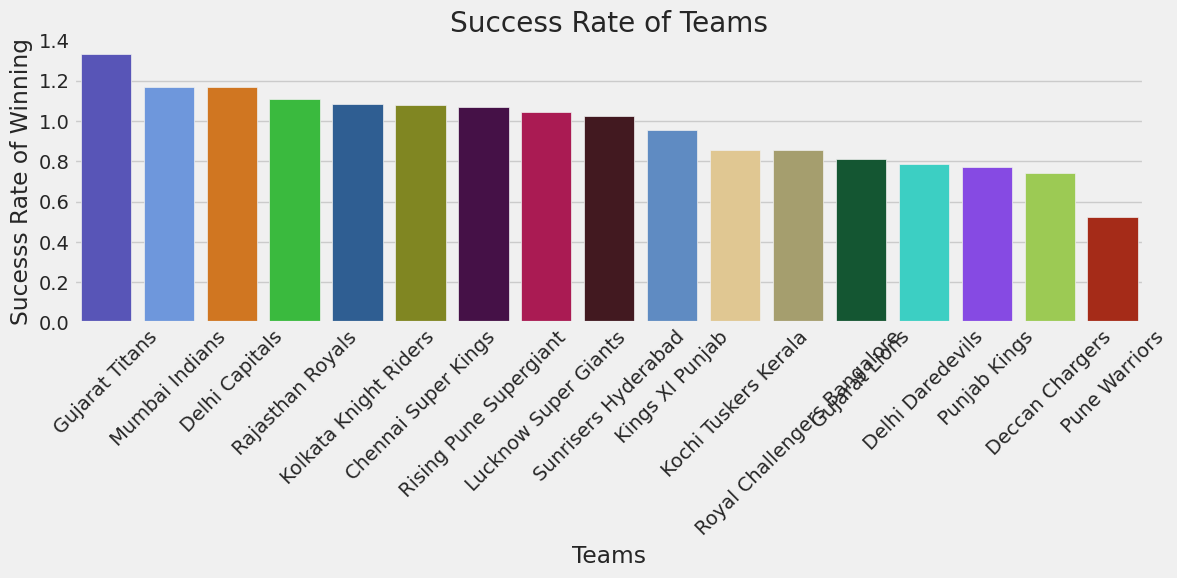

In [32]:
success_ratio = matches.groupby('winner').count()['id']/matches.groupby('team1').count()['id']
success_ratio_desc = success_ratio.sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=success_ratio_desc.index,y=success_ratio_desc.values, palette=random_colors(len(success_ratio_desc)))
plt.title('Success Rate of Teams')
plt.xlabel('Teams')
plt.ylabel('Sucesss Rate of Winning')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

Most Titles Wins


/tmp/ipykernel_1341/2271284019.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=winner_counts.index,y=winner_counts.values, palette=random_colors(len(winner_counts)))


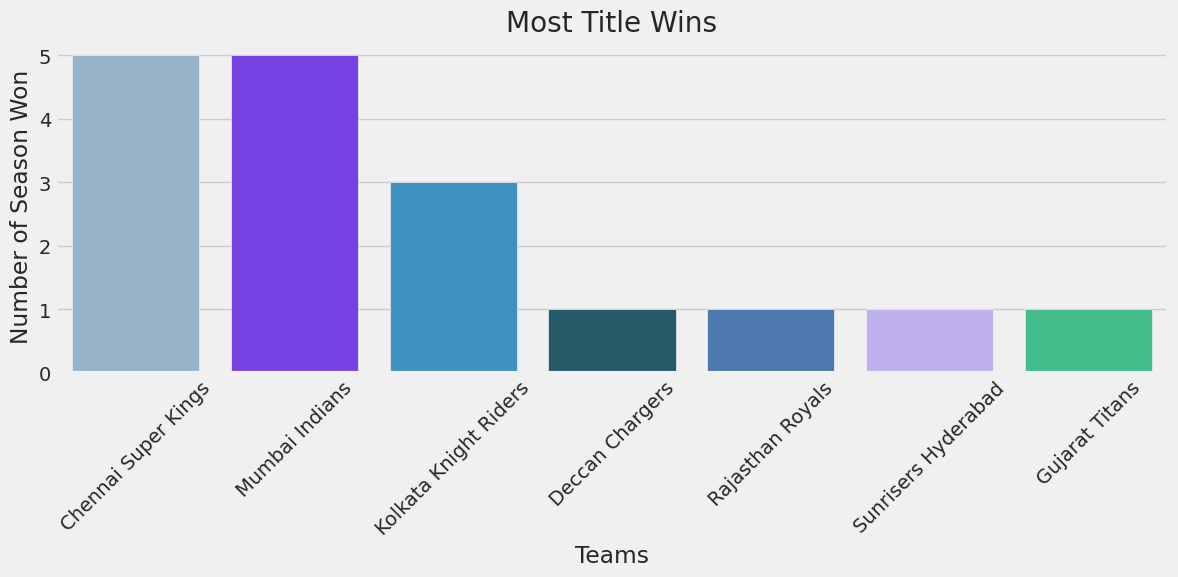

In [33]:
winner_counts = matches.groupby('season')[['season','winner']].tail(1)['winner'].value_counts()


plt.figure(figsize=(12,6))
sns.barplot(x=winner_counts.index,y=winner_counts.values, palette=random_colors(len(winner_counts)))
plt.title('Most Title Wins')
plt.xlabel('Teams')
plt.ylabel('Number of Season Won')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()


Top 10 Players with Most Runs

/tmp/ipykernel_1341/1374638685.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='batter',y='Runs', data= top_batsmen, palette=random_colors(10))


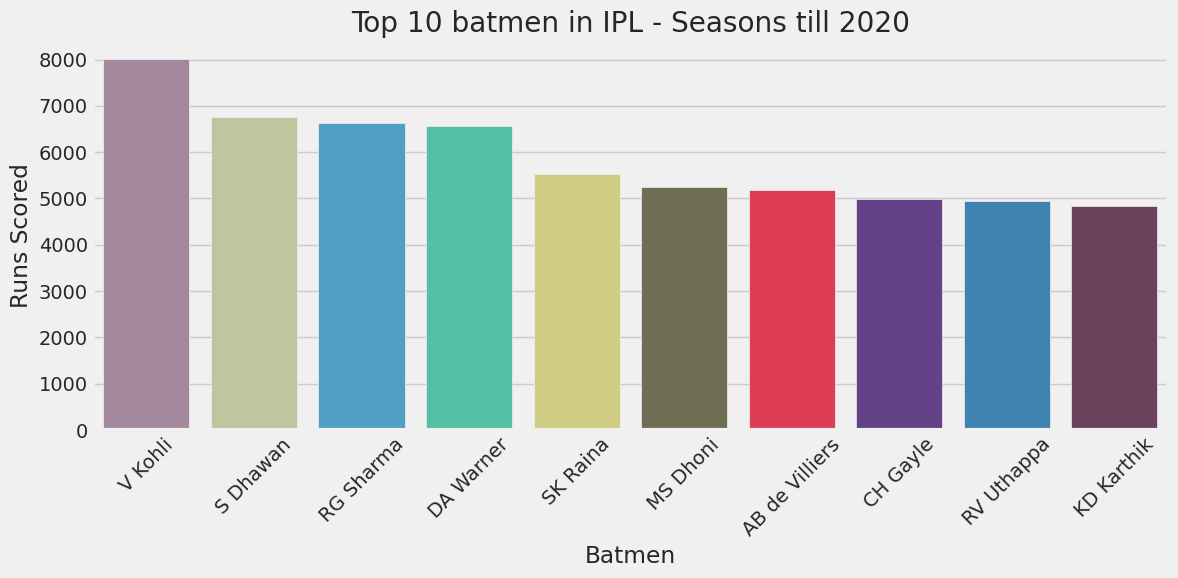

In [34]:
batting_tot = deliveries.groupby('batter')['batsman_runs'].sum().reset_index(name='Runs')
top_batsmen = batting_tot.sort_values(by='Runs',ascending=False)[:10]

plt.figure(figsize=(12,6))
sns.barplot(x='batter',y='Runs', data= top_batsmen, palette=random_colors(10))
plt.title('Top 10 batmen in IPL - Seasons till 2020')
plt.xlabel('Batmen')
plt.ylabel('Runs Scored')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()


Top 10 Best Performances in a Match

In [35]:
deliveries.head(1)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN


In [36]:
matches.head(2)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Non D/L,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,Non D/L,MR Benson,SL Shastri


In [37]:
batting_ings = deliveries.groupby(['match_id', 'batter'])['batsman_runs'].sum().reset_index(name='Innings Runs')
top_batsmen_scores = batting_ings.sort_values(by='Innings Runs',ascending=False)[:10]

In [38]:
batsman_ball_faced = deliveries.groupby(['match_id', 'batter'])['batsman_runs'].count().reset_index(name='Balls Faced')


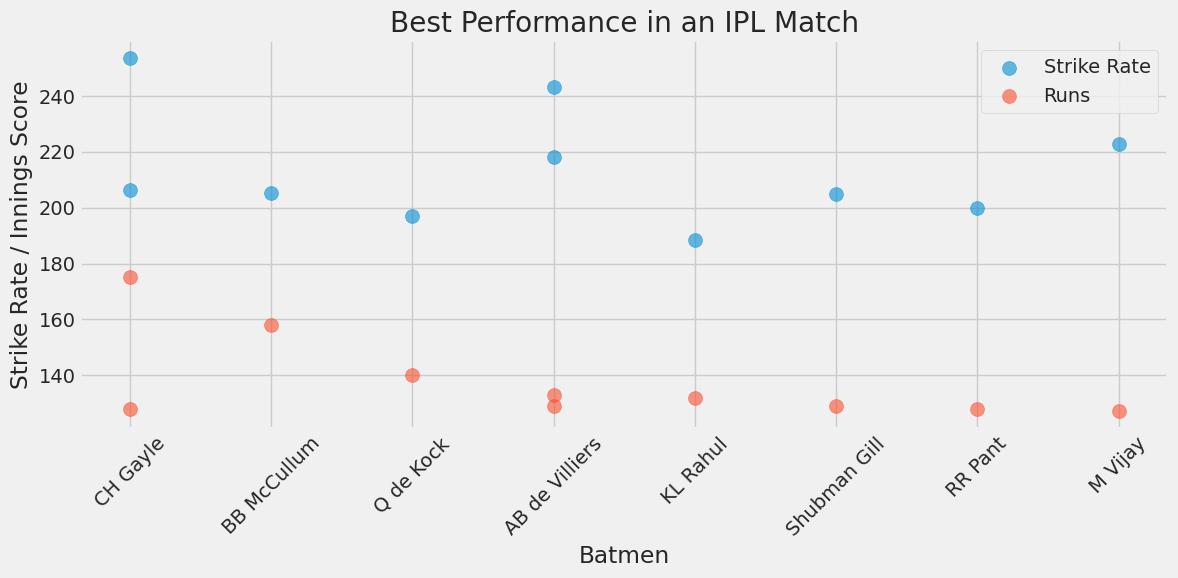

In [39]:
batsmen_performance = pd.merge(top_batsmen_scores,batsman_ball_faced,how='inner', on=['match_id','batter'])
batsmen_performance['Strike Rate for Match'] = np.round(batsmen_performance['Innings Runs']*100/batsmen_performance['Balls Faced'],2)
batsmen_performance

plt.figure(figsize=(12,6))
plt.scatter(batsmen_performance['batter'],batsmen_performance['Strike Rate for Match'], label='Strike Rate',s=100, alpha=0.6)
plt.scatter(batsmen_performance['batter'],batsmen_performance['Innings Runs'], label='Runs',s=100, alpha=0.6)
plt.title('Best Performance in an IPL Match')
plt.xlabel('Batmen')
plt.ylabel('Strike Rate / Innings Score')
plt.legend()
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()



Top 10 Bowlers till 2020


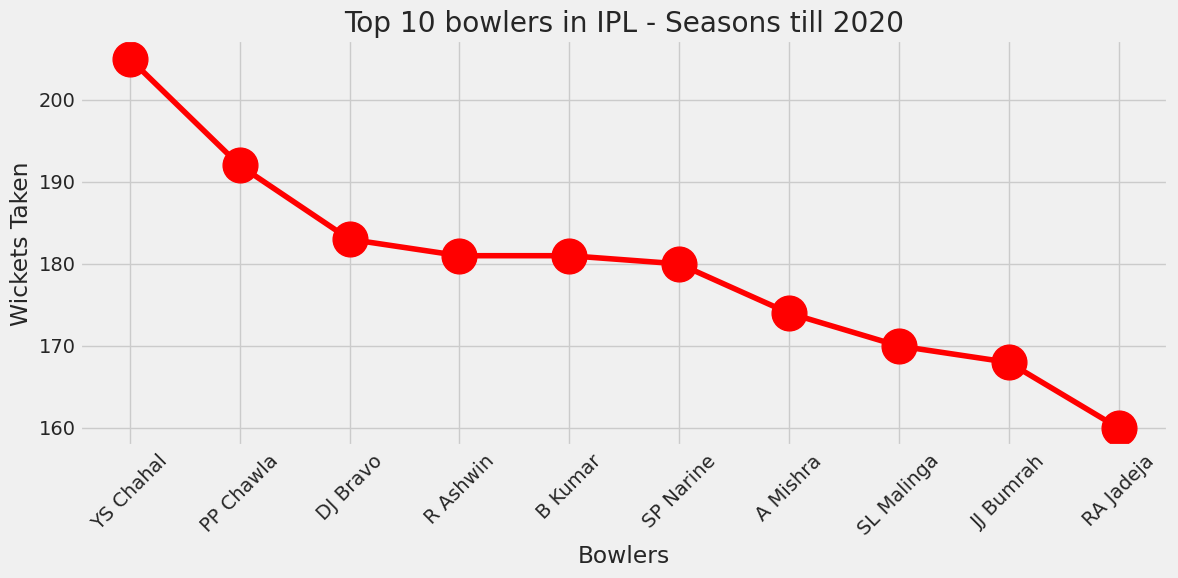

In [40]:
bowling_wickets = deliveries[deliveries['dismissal_kind'] != 'run out']
top_bowlers = bowling_wickets.groupby('bowler')['dismissal_kind'].count().reset_index(
    name='Wickets').sort_values(by='Wickets',ascending=False)[:10]

plt.figure(figsize=(12,6))
plt.plot(top_bowlers['bowler'],top_bowlers['Wickets'], marker= 'o',color='red',ms=25)
plt.title('Top 10 bowlers in IPL - Seasons till 2020')
plt.xlabel('Bowlers')
plt.ylabel('Wickets Taken')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [42]:
match_bowling_top = bowling_wickets.groupby(['match_id','bowler'])['dismissal_kind'].count().reset_index(
    name='Wickets').sort_values(by='Wickets',ascending=False)[:10]


In [43]:
match_bowler_runs = deliveries.groupby(['match_id','bowler'])['total_runs'].sum().reset_index(name='Runs Conceded')


In [44]:
match_bowler_performance = pd.merge(match_bowler_runs,match_bowling_top,how='inner', on =['match_id','bowler'])


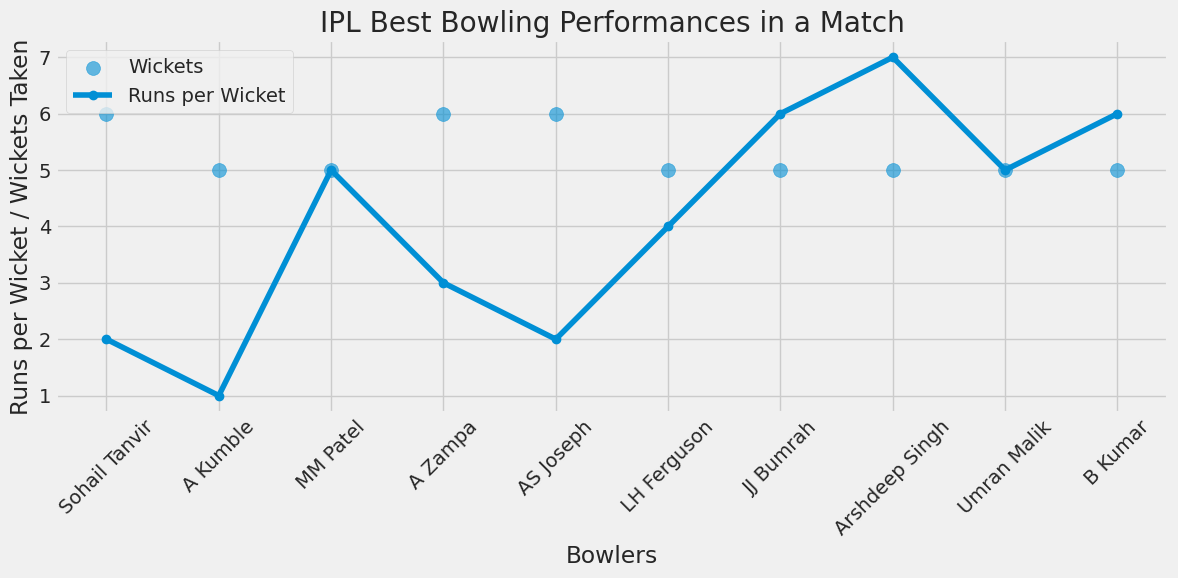

In [45]:
match_bowler_performance['Runs per Wicket'] = np.round(match_bowler_performance['Runs Conceded']/match_bowler_performance['Wickets'],0)


plt.figure(figsize=(12,6))
plt.scatter(match_bowler_performance['bowler'],match_bowler_performance['Wickets'],label='Wickets',s=100,alpha=0.6)
plt.plot(match_bowler_performance['bowler'],match_bowler_performance['Runs per Wicket'],marker='o',label='Runs per Wicket')
plt.title('IPL Best Bowling Performances in a Match')
plt.xlabel('Bowlers')
plt.ylabel('Runs per Wicket / Wickets Taken')
plt.legend()
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()



Top 10 Cities by Number of Matches

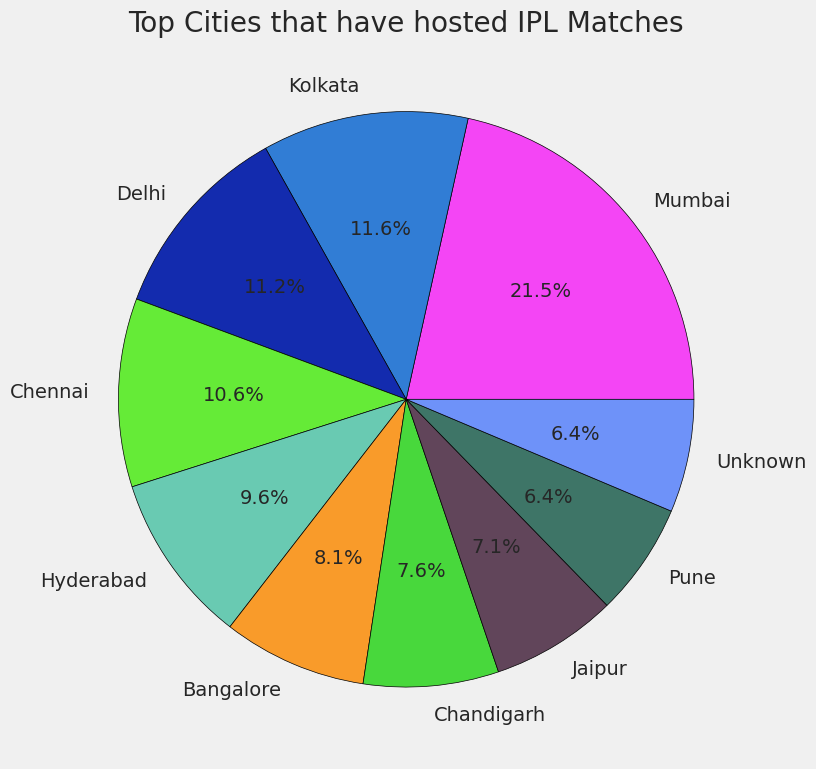

In [46]:
top_cities = matches['city'].value_counts().reset_index(name='Match Count')[:10]

plt.figure(figsize=(8,8))
plt.pie(top_cities['Match Count'], labels = top_cities['city'],colors=random_colors(10),
       autopct='%1.1f%%', wedgeprops=dict(edgecolor='black'))
plt.title('Top Cities that have hosted IPL Matches')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1341/363838552.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='dismissal_kind',data=deliveries,palette=random_colors(len(deliveries['dismissal_kind'].value_counts())))


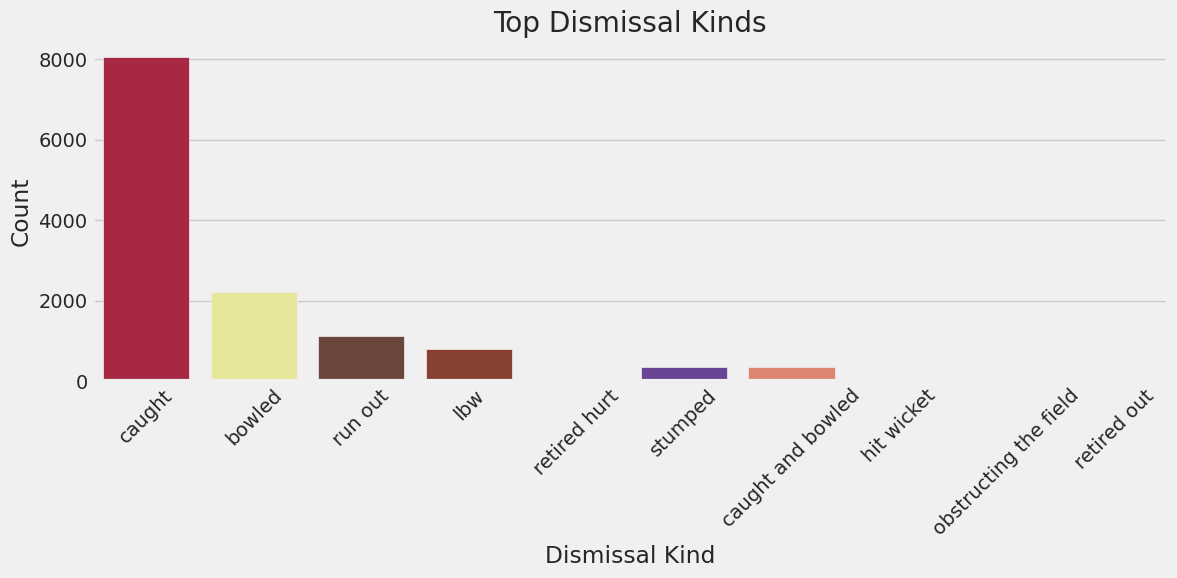

In [47]:
plt.figure(figsize=(12,6))
sns.countplot(x='dismissal_kind',data=deliveries,palette=random_colors(len(deliveries['dismissal_kind'].value_counts())))
plt.title('Top Dismissal Kinds')
plt.xlabel('Dismissal Kind')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()


Top 10 Best Fielders

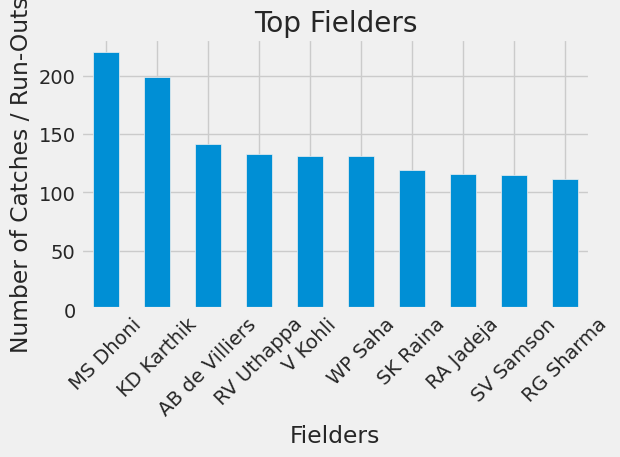

In [48]:
deliveries['fielder'].value_counts()[:10].plot(kind='bar')
plt.title('Top Fielders')
plt.xlabel('Fielders')
plt.ylabel('Number of Catches / Run-Outs')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()


Analysis Over by Over

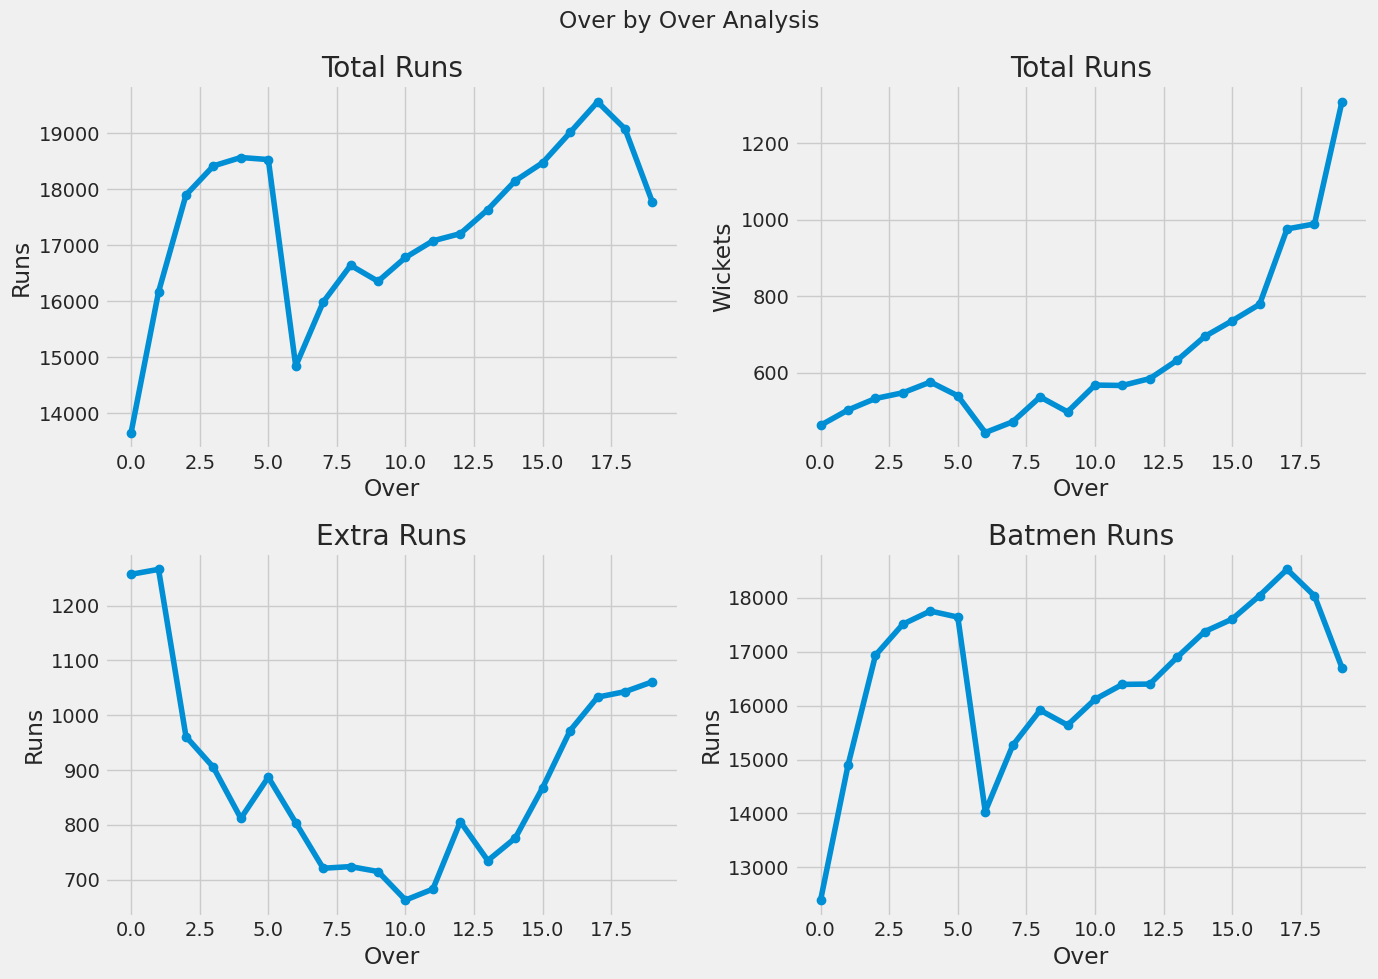

In [49]:

over_summary = deliveries.groupby('over')[['total_runs','is_wicket','extra_runs','batsman_runs']].sum()

fig, axes = plt.subplots(2,2,figsize=(14,10))
fig.suptitle('Over by Over Analysis')


axes[0,0].plot(over_summary.index,over_summary['total_runs'],marker='o')
axes[0,0].set_title('Total Runs')
axes[0,0].set_xlabel('Over')
axes[0,0].set_ylabel('Runs')

axes[0,1].plot(over_summary.index,over_summary['is_wicket'],marker='o')
axes[0,1].set_title('Total Runs')
axes[0,1].set_xlabel('Over')
axes[0,1].set_ylabel('Wickets')

axes[1,0].plot(over_summary.index,over_summary['extra_runs'],marker='o')
axes[1,0].set_title('Extra Runs')
axes[1,0].set_xlabel('Over')
axes[1,0].set_ylabel('Runs')

axes[1,1].plot(over_summary.index,over_summary['batsman_runs'],marker='o')
axes[1,1].set_title('Batmen Runs')
axes[1,1].set_xlabel('Over')
axes[1,1].set_ylabel('Runs')

plt.tight_layout()
plt.show()

Toss Decision

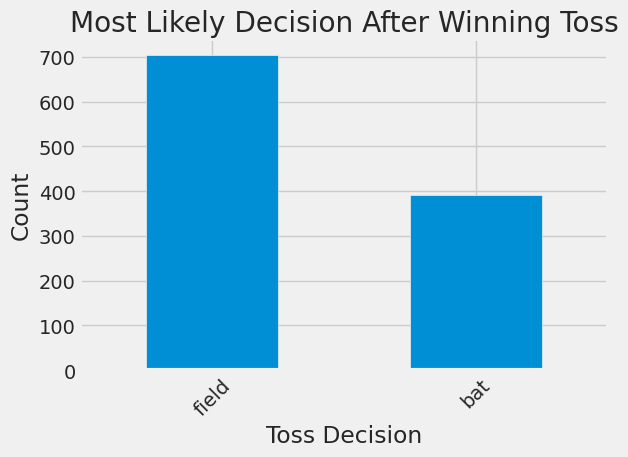

In [50]:
matches['toss_decision'].value_counts().plot(kind='bar')
plt.title('Most Likely Decision After Winning Toss')
plt.xlabel('Toss Decision')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

Toss Impact Analysis: Does winning the toss influence the match outcome?

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the number of matches won by the toss-winning team
toss_wins_match_wins = matches[matches['toss_winner'] == matches['winner']].shape[0]
total_matches = matches.shape[0]

# Calculate the percentage
win_percentage_after_toss_win = (toss_wins_match_wins / total_matches) * 100

print(f"Percentage of matches won by the team that won the toss: {win_percentage_after_toss_win:.2f}%")

# Further breakdown by toss decision
# First, identify matches where the toss winner also won the match
matches_toss_and_match_winner = matches[matches['toss_winner'] == matches['winner']]

# Group these by toss_decision and count the occurrences
toss_decision_wins = matches_toss_and_match_winner.groupby('toss_decision').size().reset_index(name='Toss Winner Match Wins')

# Get total counts for each toss decision
toss_decision_counts = matches.groupby('toss_decision').size().reset_index(name='Total Matches')

# Merge the two DataFrames
toss_analysis = pd.merge(toss_decision_counts, toss_decision_wins, on='toss_decision', how='left').fillna(0)

# Calculate win percentage
toss_analysis['Win Percentage (%)'] = (toss_analysis['Toss Winner Match Wins'] / toss_analysis['Total Matches']) * 100

display(toss_analysis)

Percentage of matches won by the team that won the toss: 50.59%


,toss_decision,Total Matches,Toss Winner Match Wins,Win Percentage (%)
0,bat,391,177,45.268542
1,field,704,377,53.551136


/tmp/ipykernel_1341/3866102912.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='toss_decision', y='Win Percentage (%)', data=toss_analysis, palette='viridis')


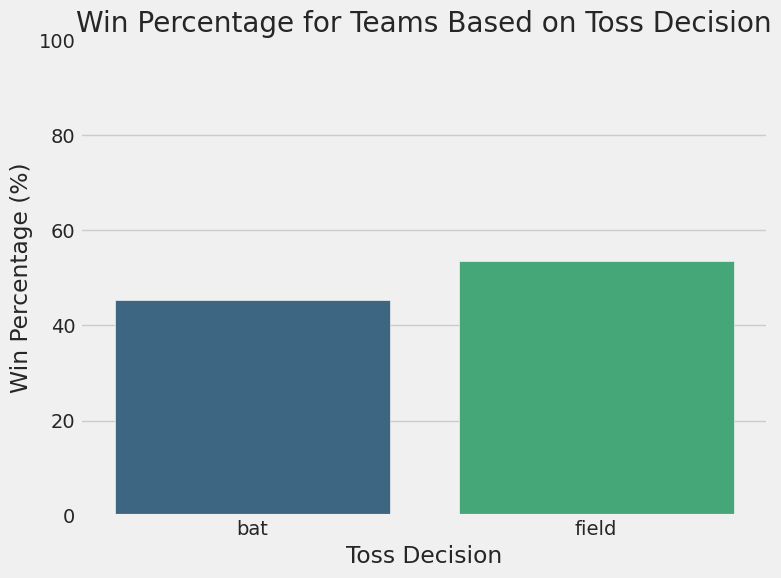

In [59]:
plt.figure(figsize=(8,6))
sns.barplot(x='toss_decision', y='Win Percentage (%)', data=toss_analysis, palette='viridis')
plt.title('Win Percentage for Teams Based on Toss Decision')
plt.xlabel('Toss Decision')
plt.ylabel('Win Percentage (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

Venue Performance Analysis: Average Runs and Wickets per Match

/tmp/ipykernel_1341/3988857422.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='avg_runs_per_match', y='venue', data=venue_performance_runs, palette='viridis')


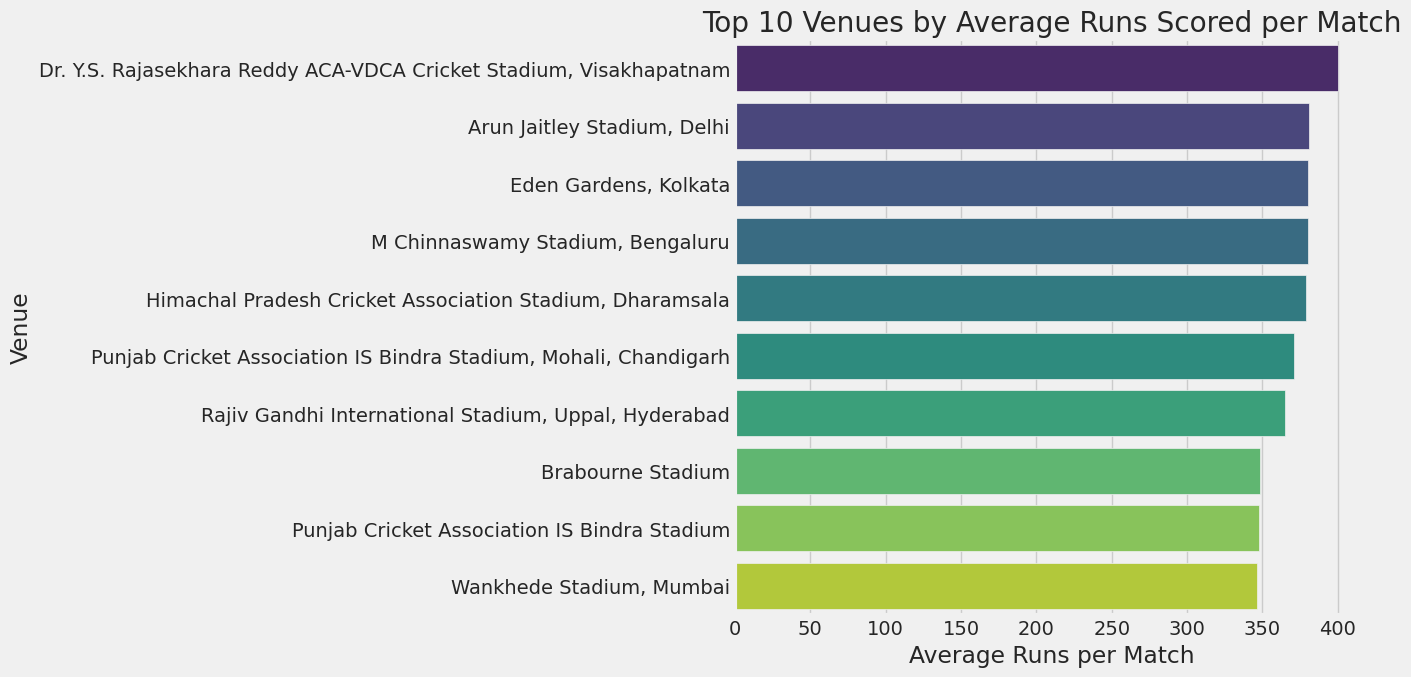

/tmp/ipykernel_1341/3988857422.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='avg_wickets_per_match', y='venue', data=venue_performance_wickets, palette='magma')


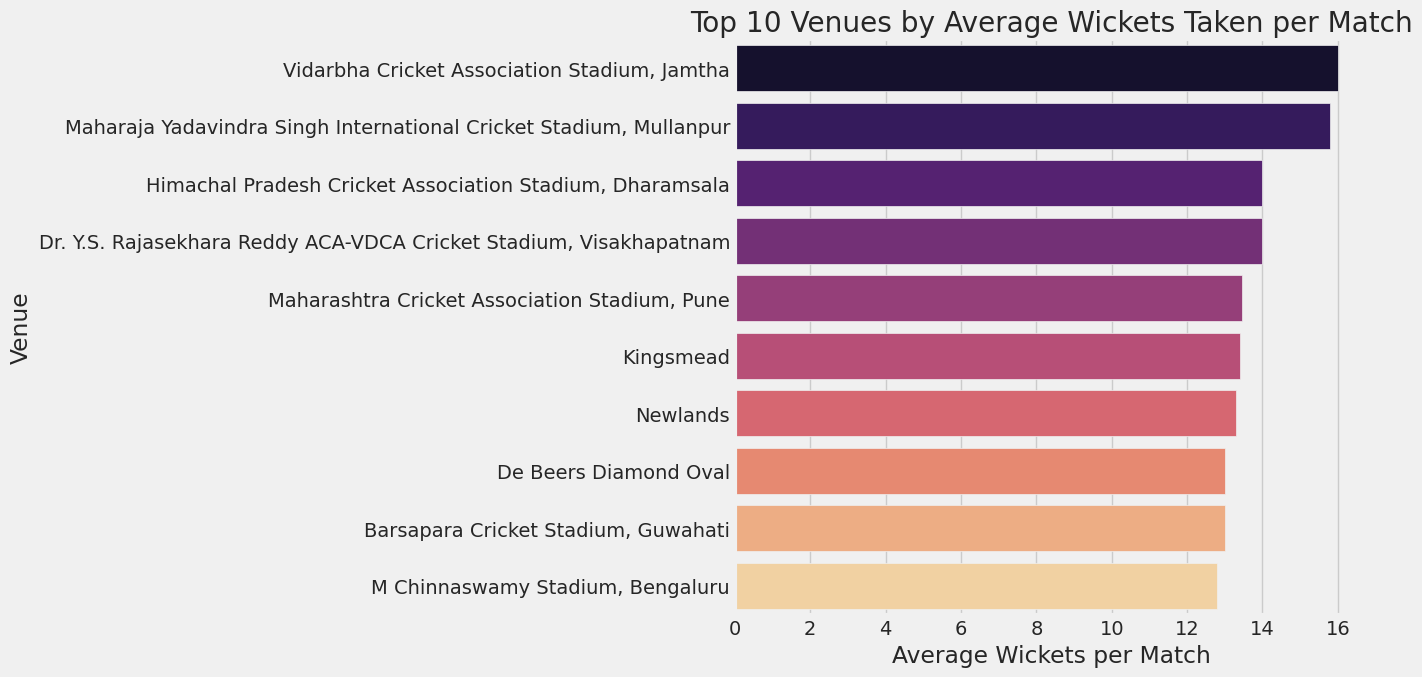

In [55]:
merged_data = pd.merge(deliveries, matches, left_on='match_id', right_on='id', how='left')

# Calculate total runs and wickets per match at each venue
venue_match_stats = merged_data.groupby(['venue', 'match_id']).agg(
    total_runs_match=('total_runs', 'sum'),
    total_wickets_match=('is_wicket', 'sum')
).reset_index()

# Calculate average runs and wickets per match for each venue
venue_performance = venue_match_stats.groupby('venue').agg(
    avg_runs_per_match=('total_runs_match', 'mean'),
    avg_wickets_per_match=('total_wickets_match', 'mean')
).reset_index()

# Sort by average runs per match for plotting
venue_performance_runs = venue_performance.sort_values(by='avg_runs_per_match', ascending=False).head(10)
venue_performance_wickets = venue_performance.sort_values(by='avg_wickets_per_match', ascending=False).head(10)

# Plotting Average Runs per Match by Venue
plt.figure(figsize=(14, 7))
sns.barplot(x='avg_runs_per_match', y='venue', data=venue_performance_runs, palette='viridis')
plt.title('Top 10 Venues by Average Runs Scored per Match')
plt.xlabel('Average Runs per Match')
plt.ylabel('Venue')
plt.tight_layout()
plt.show()

# Plotting Average Wickets per Match by Venue
plt.figure(figsize=(14, 7))
sns.barplot(x='avg_wickets_per_match', y='venue', data=venue_performance_wickets, palette='magma')
plt.title('Top 10 Venues by Average Wickets Taken per Match')
plt.xlabel('Average Wickets per Match')
plt.ylabel('Venue')
plt.tight_layout()
plt.show()

Runs Scored in Powerplay, Middle, and Death Overs

/tmp/ipykernel_1341/1224945798.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='over_phase', y='total_runs', data=runs_by_phase, palette='cividis')


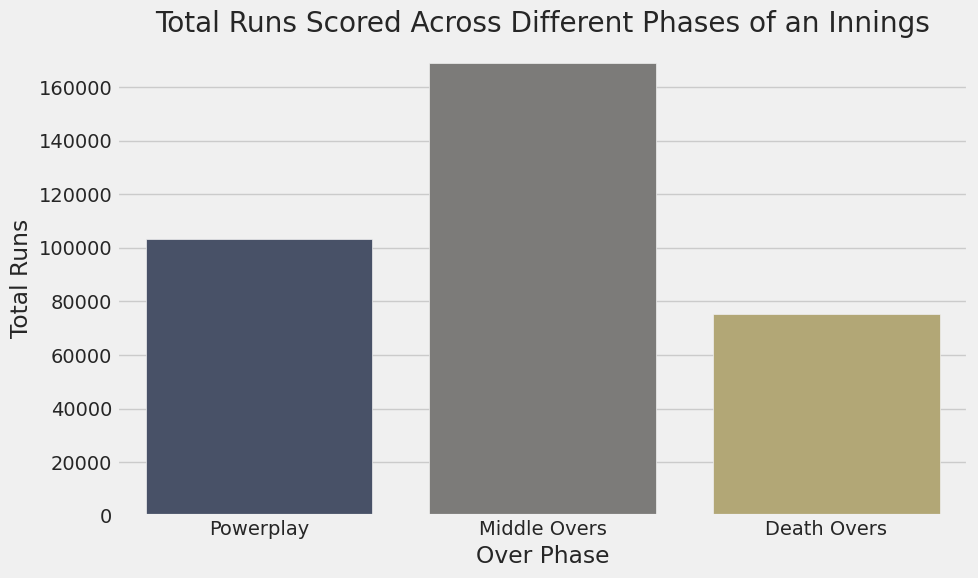

In [56]:
# Define over phases
def get_over_phase(over):
    if over >= 0 and over <= 5:
        return 'Powerplay'
    elif over >= 6 and over <= 15:
        return 'Middle Overs'
    else:
        return 'Death Overs'

deliveries['over_phase'] = deliveries['over'].apply(get_over_phase)

#total runs in each phase
runs_by_phase = deliveries.groupby('over_phase')['total_runs'].sum().reset_index()

# Order the phases for plotting
runs_by_phase['over_phase'] = pd.Categorical(runs_by_phase['over_phase'],
                                             categories=['Powerplay', 'Middle Overs', 'Death Overs'],
                                             ordered=True)
runs_by_phase = runs_by_phase.sort_values('over_phase')

plt.figure(figsize=(10, 6))
sns.barplot(x='over_phase', y='total_runs', data=runs_by_phase, palette='cividis')
plt.title('Total Runs Scored Across Different Phases of an Innings')
plt.xlabel('Over Phase')
plt.ylabel('Total Runs')
plt.tight_layout()
plt.show()